In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import Input
import os

In [2]:
print(tf.config.list_physical_devices('GPU'))
print(len(tf.config.list_physical_devices('GPU')))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
1


In [3]:
# Set dataset path
data_dir = r'D:\Project\data_kaggle\aug\train_split'

In [4]:
batch_size = 32
img_height = 224
img_width = 224
image_size = (img_height, img_width)
epochs = int(input("Enter epochs number: "))

Enter epochs number:  90


In [5]:
train_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb'  # Force RGB mode
)

Found 5863 images belonging to 8 classes.


In [6]:
val_datagen = ImageDataGenerator()

val_data = r"D:\Project\data_kaggle\aug\val_split"

val_generator = val_datagen.flow_from_directory(
    val_data,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
)

Found 1469 images belonging to 8 classes.


In [7]:


# Load MobileNetV2 without the top layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers (optional)
base_model.trainable = False  # Set to True if you want to fine-tune later

# Custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Pooling for MobileNet outputs
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)  # Dropout for regularization
output = Dense(len(train_generator.class_indices), activation='softmax')(x)  # Output layer

# Define the final model
model = Model(inputs=base_model.input, outputs=output)

In [8]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
Conv1 (Conv2D)                  (None, 112, 112, 32) 864         input_1[0][0]                    
__________________________________________________________________________________________________
bn_Conv1 (BatchNormalization)   (None, 112, 112, 32) 128         Conv1[0][0]                      
__________________________________________________________________________________________________
Conv1_relu (ReLU)               (None, 112, 112, 32) 0           bn_Conv1[0][0]                   
______________________________________________________________________________________________

In [9]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),  # Lower LR for better training stability
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
# Train the model
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)

Epoch 1/90
184/184 [==============================] - 68s 281ms/step - loss: 2.1352 - accuracy: 0.2229 - val_loss: 1.7329 - val_accuracy: 0.3853
Epoch 2/90
184/184 [==============================] - 49s 265ms/step - loss: 1.7362 - accuracy: 0.3532 - val_loss: 1.5484 - val_accuracy: 0.4765
Epoch 3/90
184/184 [==============================] - 49s 264ms/step - loss: 1.5705 - accuracy: 0.4254 - val_loss: 1.4086 - val_accuracy: 0.5337
Epoch 4/90
184/184 [==============================] - 49s 265ms/step - loss: 1.4509 - accuracy: 0.4791 - val_loss: 1.3251 - val_accuracy: 0.5480
Epoch 5/90
184/184 [==============================] - 45s 244ms/step - loss: 1.3699 - accuracy: 0.5139 - val_loss: 1.2524 - val_accuracy: 0.5909
Epoch 6/90
184/184 [==============================] - 46s 250ms/step - loss: 1.2871 - accuracy: 0.5480 - val_loss: 1.1931 - val_accuracy: 0.6208
Epoch 7/90
184/184 [==============================] - 46s 251ms/step - loss: 1.2266 - accuracy: 0.5753 - val_loss: 1.1523 - val_ac

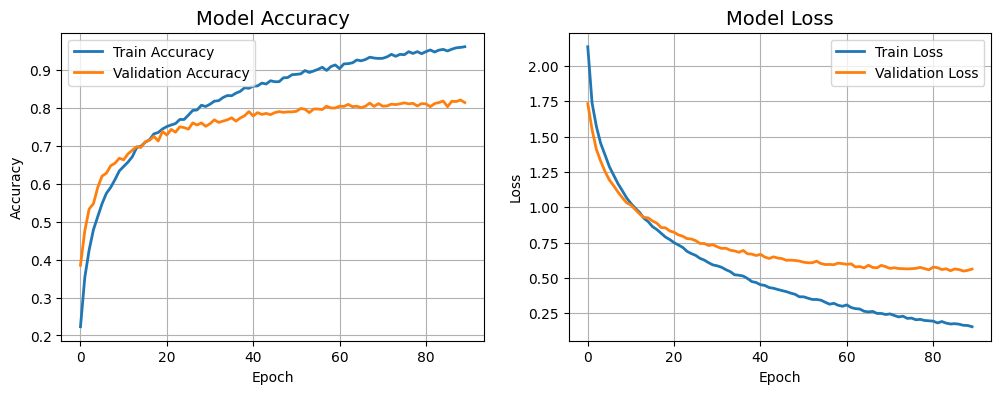

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [12]:
# Evaluate model
test_data = r'D:\Project\data_kaggle\test'

eval_generator = train_datagen.flow_from_directory(
    test_data,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

y_true = eval_generator.classes
y_pred = model.predict(eval_generator)

# Convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)  # Fix tf.argmax issue

Found 190 images belonging to 8 classes.


In [13]:
# Print classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred_classes))

# Plot confusion matrix
conf_mat = confusion_matrix(y_true, y_pred_classes)
class_labels = list(train_generator.class_indices.keys())


Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.46      0.52        28
           1       0.67      0.86      0.75        21
           2       0.79      0.60      0.68        25
           3       0.72      0.78      0.75        23
           4       0.54      0.62      0.58        21
           5       0.71      0.74      0.72        23
           6       0.79      0.85      0.81        26
           7       0.95      0.87      0.91        23

    accuracy                           0.72       190
   macro avg       0.72      0.72      0.72       190
weighted avg       0.72      0.72      0.71       190



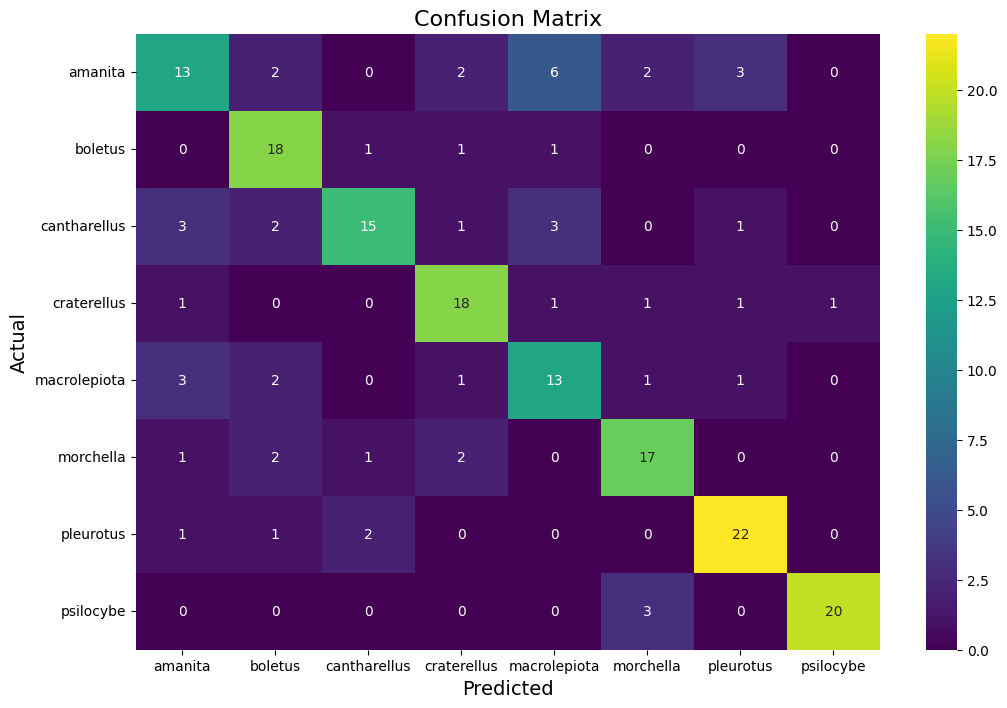

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="viridis", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.show()

In [15]:
model_version = epochs
next_version = str(int(model_version) + 10)

In [16]:
import shutil

notebook_filename = f"CNN_{model_version}_ADAM.ipynb"
new_notebook_filename = f"CNN_{next_version}_ADAM.ipynb"

shutil.copy(notebook_filename, new_notebook_filename)
print(f"Notebook copied as {new_notebook_filename}")

Notebook copied as CNN_100_ADAM.ipynb


In [ ]:
os._exit(00)